# 第018单元 期望方差与抽样误差

## Goal
为什么64行记录有时只包含8个独立抽样单位？从精确有限和算起，用已知合成生成器检验均值误差。主例4个等权编号对应0、0、2、6。先修017离散部分，无需连续积分。区分单个观测SD、单批均值SE、4000批模拟平均的MCSE。

## Setup
在本单元目录启动内核，重启并运行全部。统计核心只用标准库；IPython显示已提供的原图。 固定图文与Notebook仅接受原始配置及对应outputs；自定义模拟须用脚本另存，不能把新配置混进本Notebook。

In [1]:
from pathlib import Path
from fractions import Fraction as F
import csv, math, sys
from IPython.display import display, Image
from experiment import (finite_moments, covariance, sample_statistics,
    exact_mean_distribution, sample_mean_variance, run, checked_config, require_teaching_config)
require_teaching_config()  # Refuse a custom config or mismatched outputs before display/write.
print("Python", sys.version.split()[0])

Python 3.12.14


## Steps
### 1 精确总体矩
两个0原子必须保留，整数质量2、1、1归一化为1/2、1/4、1/4。

In [2]:
mu, e2, var = finite_moments([0,2,6],[2,1,1])
assert (mu,e2,var) == (2,10,6)
print("E[X], E[X²], Var(X):",mu,e2,var)
print("E[X²]与E[X]²:",e2,mu*mu)

E[X], E[X²], Var(X): 2 10 6
E[X²]与E[X]²: 10 4


### 2 零协方差仍有依赖
X均匀取−1、0、1，Y=X²。

In [3]:
assert covariance([-1,0,1],[1,0,1],[1,1,1]) == 0
print("Cov(X,X²)=0; P(Y=0|X=0)=1, P(Y=0)=1/3")

Cov(X,X²)=0; P(Y=0|X=0)=1, P(Y=0)=1/3


### 3 精确均值分布
计数卷积不使用随机数，不是先去重再均匀抽样。

In [4]:
law=exact_mean_distribution([0,0,2,6],2)
print([(str(x),str(p)) for x,p in law])
assert sum(p for x,p in law)==1
assert sum(x*p for x,p in law)==2
assert sum((x-2)**2*p for x,p in law)==3

[('0', '1/4'), ('1', '1/4'), ('2', '1/16'), ('3', '1/4'), ('4', '1/8'), ('6', '1/16')]


### 4 分布集中
各图都是离散概率质量；纵轴缩放不同，应比较横向宽度与6/n。

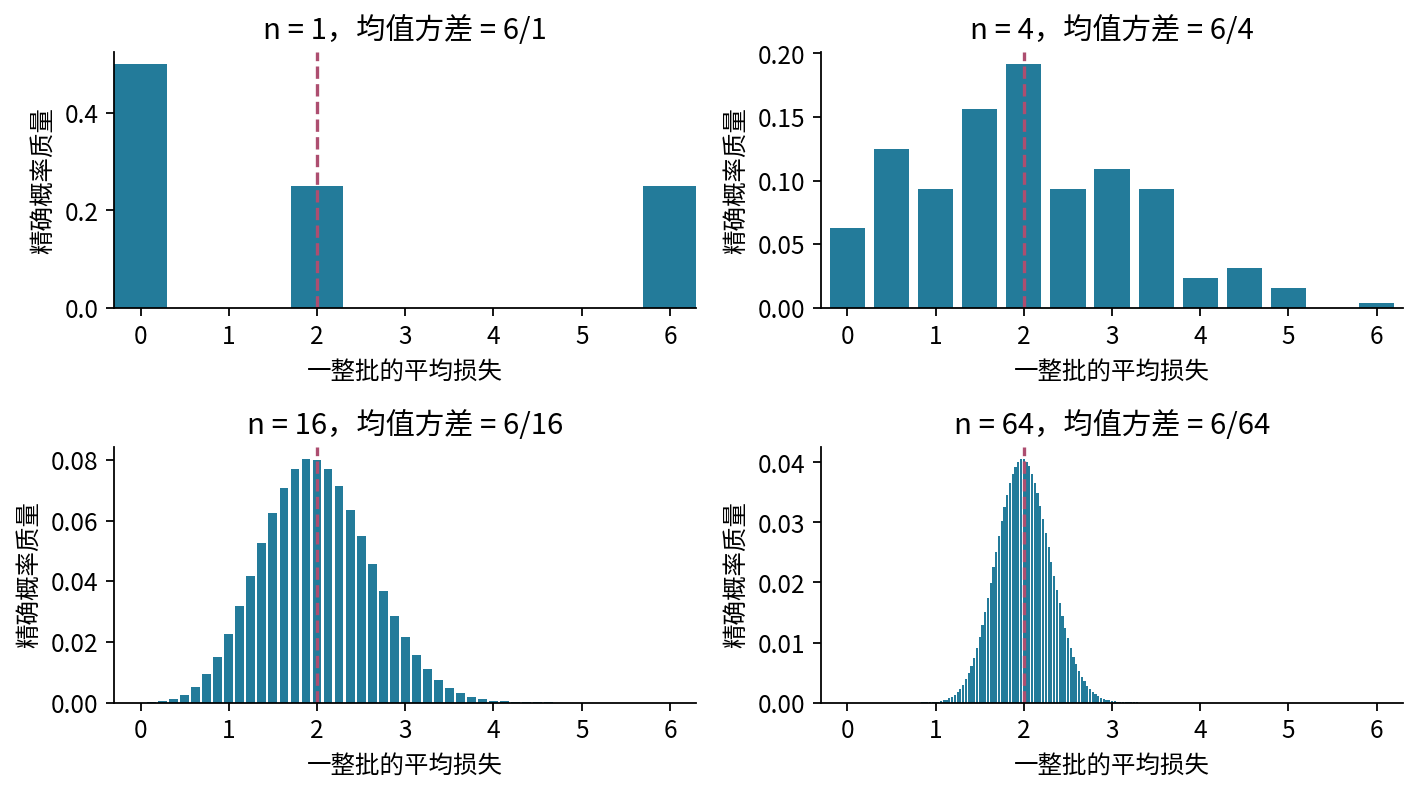

In [5]:
display(Image(filename="figures/04_exact_sampling.png",width=740))

### 5 保留组ID
8个固定组值专用于手算，没有从模拟中挑选最好的一批。

In [6]:
with Path("data/group_observations.csv").open() as stream:
    rows=list(csv.DictReader(stream))
assert [r["group_id"] for r in rows]==[str(i) for i in range(1,9)]
groups=[int(r["loss"]) for r in rows]
mean,s2,se2=sample_statistics(groups)
assert (mean,s2,se2)==(2,F(48,7),F(6,7))
print("mean, s², estimated SE²:",mean,s2,se2)
print("estimated SE:",math.sqrt(float(se2)))

mean, s², estimated SE²: 2 48/7 6/7
estimated SE: 0.9258200997725514


### 6 复制不新增独立组
固定样本的两种估计方差比9，两个生成机制的真实方差比8，比较对象不同。

In [7]:
copied=[x for x in groups for _ in range(8)]
row_mean,row_s2,row_se2=sample_statistics(copied)
assert (row_mean,row_s2,row_se2)==(2,F(128,21),F(2,21))
assert se2/row_se2==9
assert sample_mean_variance(6,64,8)/sample_mean_variance(6,64)==8
print("错误逐行SE:",math.sqrt(float(row_se2)),"正确逐组SE:",math.sqrt(float(se2)))

错误逐行SE: 0.3086066999241838 正确逐组SE: 0.9258200997725514


### 7 实际生成4000批
此调用运行全部32000个整批试验，写notebook_outputs。n是行数，复制机制G=n/8；R=4000是外层独立批次数。

In [8]:
results,summary=run(Path("notebook_outputs"))
assert len(summary)==8
for r in summary:
    print(r["mode"],r["n"],"empirical SD",round(r["empirical_sd"],6),"true SE",round(r["true_se"],6))

iid 16 empirical SD 0.621483 true SE 0.612372
copied_groups 16 empirical SD 1.724899 true SE 1.732051
iid 32 empirical SD 0.432354 true SE 0.433013
copied_groups 32 empirical SD 1.242048 true SE 1.224745
iid 64 empirical SD 0.308198 true SE 0.306186
copied_groups 64 empirical SD 0.877561 true SE 0.866025
iid 128 empirical SD 0.21926 true SE 0.216506
copied_groups 128 empirical SD 0.61214 true SE 0.612372


### 8 模拟平均的MCSE
它描述4000个批均值再平均的波动，不是现实单批获得额外4000倍证据。

In [9]:
for r in summary:
    if r["n"]==64:
        assert math.isclose(r["mcse_of_mean_of_means"],r["empirical_sd"]/math.sqrt(4000))
        print(r["mode"],"mean of means",round(r["mean_of_means"],6),"MCSE",round(r["mcse_of_mean_of_means"],6))

iid mean of means 2.009461 MCSE 0.004873
copied_groups mean of means 2.017688 MCSE 0.013875


### 9 核对尺度
RMS表示先平方再平均再开方，针对方差无偏性比较。固定copies时增加n同时增加独立组数。

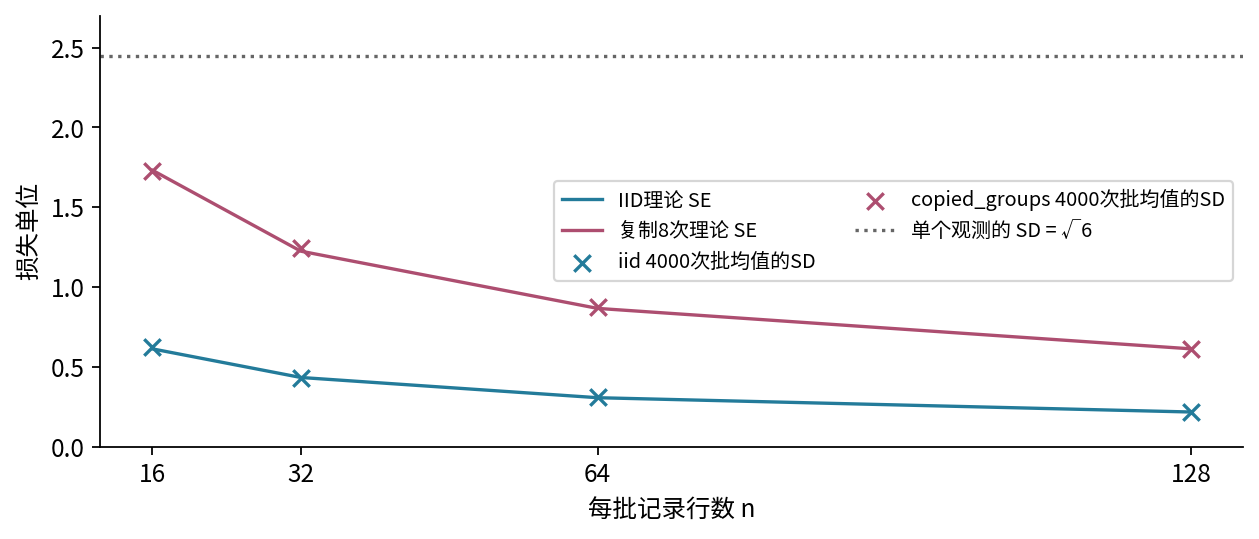

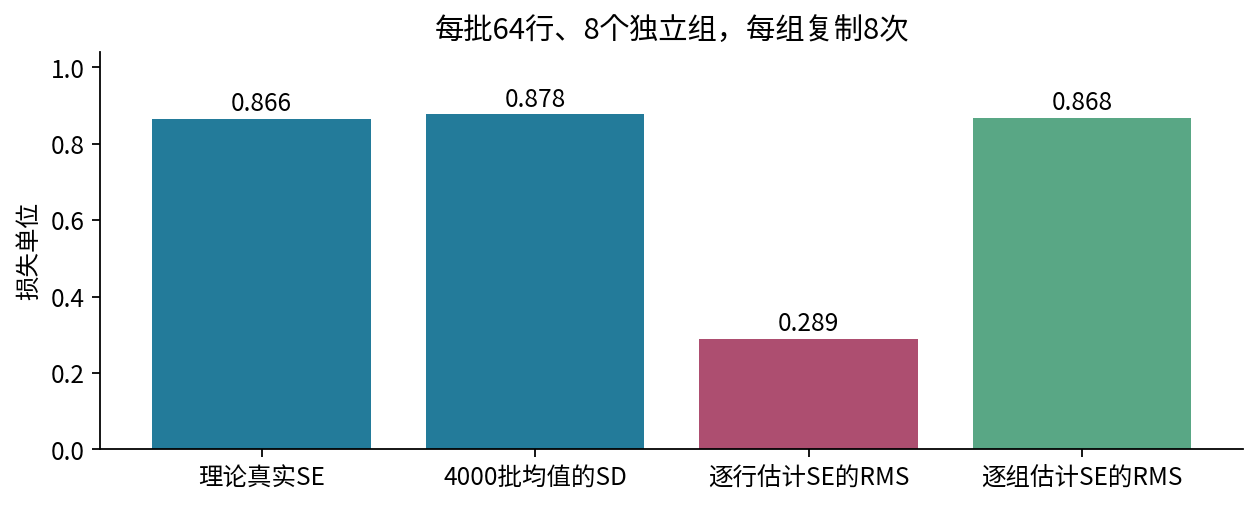

In [10]:
display(Image(filename="figures/06_sd_se.png",width=740))
display(Image(filename="figures/07_se_estimation.png",width=740))

### 10 罕见事件与零经验SE
超过90%的批次全零，但真实SE非零。

In [11]:
all_zero=F(999,1000)**100
_,zero_s2,zero_se2=sample_statistics([0]*100)
true_se=math.sqrt(float(F(1,1000)*F(999,1000)/100))
assert zero_se2==0
print("P(all zero)",float(all_zero),"observed SE",0,"true SE",true_se)

P(all zero) 0.904792147113709 observed SE 0 true SE 0.0031606961258558216


### 11 大数界与永久复制
ε=0.5时显示的是概率上界，不是准确比例。永久复制的偏差不随n消失。

In [12]:
for n in [64,256]:
    print(n,"Chebyshev bound",min(F(1),F(6)/(n*F(1,2)**2)))
assert sum(p for x,p in [(0,F(1,2)),(2,F(1,4)),(6,F(1,4))] if abs(x-2)>=1)==F(3,4)

64 Chebyshev bound 3/8
256 Chebyshev bound 3/32


## Checks
### 12 拒绝非法复制数
边界失败必须明确，不允许静默修正采样机制。完整测试还保护已有输出。

In [13]:
bad=dict(results["config"],copies=0)
try:
    checked_config(bad)
except ValueError as error:
    print("已拒绝:",error)
else:
    raise AssertionError("非法复制数必须拒绝")

已拒绝: copies must be an integer in [2, 100]


### 13 和脚本结果逐字节比较
如果修改过代码或配置，应保留变化记录并重跑，不能替换文件伪造一致。

In [14]:
for name in ["results.json","sampling_trials.csv","sampling_summary.csv","environment.json"]:
    assert (Path("outputs")/name).read_bytes()==(Path("notebook_outputs")/name).read_bytes()
print("4 output files are byte-identical")

4 output files are byte-identical


## Next Steps
n=64时理论SE分别0.30619与0.86603，模拟SD分别0.30820与0.87756。完成正文14题，说明独立单位与误差对象。

已实际执行真实InProcessKernel；未实测全新Anaconda安装、浏览器Jupyter、socket内核传输或跨平台环境。合成机制不证明真实数据独立或泛化。来源见lecture.md及source-checks.json。